# The art of using t-SNE for single-cell transcriptomics. Tutorial. 

This tutorial uses the data set from https://www.nature.com/articles/s41586-018-0654-5.

This notebook is self-contained. All functions that one needs to run this notebook are defined below.

Please install FIt-SNE from https://github.com/KlugerLab/FIt-SNE.

In [3]:
# Prepare

#%matplotlib notebook - removed as prevented plotting!
%matplotlib inline

import numpy as np
import pylab as plt
import seaborn as sns; sns.set_theme()
import pandas as pd
import pickle
import scipy
import matplotlib
from scipy import sparse
import sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

In [5]:
# import tsne
import os
import sys
sys.path.append(os.path.expanduser('~/FIt-SNE'))
from fast_tsne import fast_tsne

In [7]:
print('Python version', sys.version)
print('Numpy', np.__version__)
print('Matplotlib', matplotlib.__version__)
print('Seaborn', sns.__version__)
print('Pandas', pd.__version__)
print('Scipy', scipy.__version__)
print('Sklearn', sklearn.__version__)

Python version 3.8.19 (default, Mar 20 2024, 15:00:34) 
[Clang 14.0.6 ]
Numpy 1.24.3
Matplotlib 3.7.2
Seaborn 0.12.2
Pandas 1.5.3
Scipy 1.9.1
Sklearn 1.2.2


## Load the data
Download the data from here: http://celltypes.brain-map.org/rnaseq and unpack. Direct links:
 * VISp: http://celltypes.brain-map.org/api/v2/well_known_file_download/694413985
 * ALM: http://celltypes.brain-map.org/api/v2/well_known_file_download/694413179

To get the information about cluster colors and labels (`sample_heatmap_plot_data.csv`), open the interactive data browser http://celltypes.brain-map.org/rnaseq/mouse/v1-alm, go to "Sample Heatmaps", click "Build Plot!" and then "Download data as CSV". For later reproducibility, this file is also provided in this github repository (`data` folder).

## Data download notes
The data files contain RNA sequencing data of single cells isolated from either the mouse primary visual cortex (VISp) or anterior lateral motor cortical area (ALM). For both, sequencing results were aligned either to exons or introns in the GRCm38.p3 reference genome using the STAR algorithm, and aggregated counts at the gene level were calculated. I this tutorial we are using read counts obtained for each (gene, sample) pair based on alignment to **exons**. Row 1 (python index 0) contains the unique identifiers of the samples (cells) and column 1 (python index 0) contains the unique identifiers of the genes.

### SciPy API update  
The sparseload function is used to read data from two large datasets in chunks (of 1000). It returns the gene count, gene ID, cell ID, and brain area (`counts, genes, cells, areas`). The function uses the scipy.sparse module which contains functions to deal with sparse data. Sparse data is data that has mostly unused elements (elements that don't carry any information, e.g. when there are a lot of 0 values). In the original function sparse blocks were created by using the sparse.csr_matrix() function, however from version 1.18.0 SciPy sparse is shifting from a sparse matrix interface to a sparse array interface. Therefore **I will aim to adjust the code to be array compliant** as per the instructions here: [https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html#migration-to-sparray](https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html#migration-to-sparray), bearing in mind that downstream calculations might expect a sparse matrix and not an array.  

### sparseload function  
The function creates 4 empty lists to receive data relating to genes, sparseblocks, areas, and cells. Data is read from two separate .CSV files, as specified by the user, in chunks of 1000, where the data from the first file is referred to as chunk1, and the data from the second file is referred to as chunk2. When the function is first called the cells list will be empty (i.e. `len(cells) == 0` will be `True`) and therefore `cells` will be assigned the output created by joining (concatenating) the column names of chunk1 and chunk2 as a NumPy array. In addition, the areas list is filled with zeros and ones, the number of which is equal to the number of columns in file 1 (in former case) and number of columns in file 2 (in latter case). So the two brain areas are coded as: `primary visual cortex (VISp) = 0` and `anterior lateral motor cortical area (ALM) = 1`. All subsequent iterations of the for loop will skil this step (as `len(cells)==0` will be `False`.  

For every subsequent chunk of 1000 rows, the gene names in the indices of the specific row is added to the `genes` list. After that, the values in each chunk is converted to a sparse array (only the non-zero values and their positions are stored), and the chunks from the two different files are stacked horizontally (equivalent to cbind() in R). Finally these stacked sparse blocks are added to the `sparseblocks` list.  

The line `print('.', end='', flush=True)` causes a dot to be printed to screen every time a (chunk1, chunk2) pair passes through the `for` loop.  

When all chunks are read, the sparseblocks created from them are converted into a count matrix for downstream applications. The function then returns the counts (as an inverse matrix), the gene names as a NumPy array, the cell IDs (a list), and the brain areas (either 0 or 1) as a NumPy array.  

**Note:** It appears that the data is cleaned up by applying input from a previous analysis ("tasic-sample_heatmap_plot_data.csv"). 

In [11]:
%%time

# Load the Allen institute data. This takes a few minutes

# This function is needed because using Pandas to load these files in one go 
# can eat up a lot of RAM. So we are doing it in chunks, and converting each
# chunk to the sparse matrix format on the fly.
def sparseload(filenames):
    genes = []
    sparseblocks = []
    areas = []
    cells = []
    for chunk1,chunk2 in zip(pd.read_csv(filenames[0], chunksize=1000, index_col=0, na_filter=False),
                             pd.read_csv(filenames[1], chunksize=1000, index_col=0, na_filter=False)):
        if len(cells)==0:
            cells = np.concatenate((chunk1.columns, chunk2.columns))
            areas = [0]*chunk1.columns.size + [1]*chunk2.columns.size
        
        genes.extend(list(chunk1.index))
        sparseblock1 = sparse.csr_array(chunk1.values.astype(float))
        sparseblock2 = sparse.csr_array(chunk2.values.astype(float))
        sparseblock = sparse.hstack((sparseblock1,sparseblock2), format='csr')
        sparseblocks.append([sparseblock])
        print('.', end='', flush=True)
    print(' done')
    counts = sparse.bmat(sparseblocks)
    return (counts.T, np.array(genes), cells, np.array(areas))

filenames = ['data/mouse_VISp_gene_expression_matrices_2018-06-14/mouse_VISp_2018-06-14_exon-matrix.csv',
             'data/mouse_ALM_gene_expression_matrices_2018-06-14/mouse_ALM_2018-06-14_exon-matrix.csv']
counts, genes, cells, areas = sparseload(filenames)

# read file with cols: gene_symbol, gene_id, chromosome, gene_entrez_id, gene_name
# create dictionary with gene_id keys and gene_symbol values
# look up value associated with gene_id as stored in `genes` list, and swap with gene_symbol
genesDF = pd.read_csv('data/mouse_VISp_gene_expression_matrices_2018-06-14/mouse_VISp_2018-06-14_genes-rows.csv')
ids     = genesDF['gene_entrez_id'].tolist()
symbols = genesDF['gene_symbol'].tolist()
id2symbol = dict(zip(ids, symbols))
genes = np.array([id2symbol[g] for g in genes])

# read cluster info and convert columns to NumPy arrays
clusterInfo = pd.read_csv('data/tasic-sample_heatmap_plot_data.csv')
goodCells  = clusterInfo['sample_name'].values
ids        = clusterInfo['cluster_id'].values
labels     = clusterInfo['cluster_label'].values
colors     = clusterInfo['cluster_color'].values

# get cluster labels and colours
clusterNames  = np.array([labels[ids==i+1][0] for i in range(np.max(ids))])
clusterColors = np.array([colors[ids==i+1][0] for i in range(np.max(ids))])
clusters   = np.copy(ids) - 1

# find rows with "good" cells and package verything into a dictionary that contains objects (e.g. gene count matrix) to be used downstream
ind = np.array([np.where(cells==c)[0][0] for c in goodCells])
counts = counts[ind, :]

tasic2018 = {'counts': counts, 'genes': genes, 'clusters': clusters, 'areas': areas, 
             'clusterColors': clusterColors, 'clusterNames': clusterNames}
counts = []

.............................................. done
CPU times: user 1min 57s, sys: 8.41 s, total: 2min 6s
Wall time: 2min 7s


In [13]:
print('Number of cells:', tasic2018['counts'].shape[0])
print('Number of cells from ALM:', np.sum(tasic2018['areas']==0))
print('Number of cells from VISp:', np.sum(tasic2018['areas']==1))
print('Number of clusters:', np.unique(tasic2018['clusters']).size)
print('Number of genes:', tasic2018['counts'].shape[1])
print('Fraction of zeros in the data matrix: {:.2f}'.format(
    tasic2018['counts'].size/np.prod(tasic2018['counts'].shape)))

Number of cells: 23822
Number of cells from ALM: 15413
Number of cells from VISp: 10068
Number of clusters: 133
Number of genes: 45768
Fraction of zeros in the data matrix: 0.20


## Pre-processing

The data set consists of thousands of cells, each of which has expression data for thousands of genes. One of the challenges in big data analysis is the large number of features (dimensions) which can cause computational issues. Here the authors have done feature selection by calculating the mean expression of a gene among cells where it is detected, as well as the proportion of cells where the gene is near-zero, setting a threshold on both and selecting only the top 3000 genes that have unusally high detection frequency relative to expression level. The plot shows that a lot of genes will be filtered out through feature selection (selectedGenes creates a Boolean mask to apply to our data set). 

In [18]:
%%time

# Feature selection

# function that identifies proportion of cells in which the gene has expression =< threshold
def nearZeroRate(data, threshold=0):
    zeroRate = 1 - np.squeeze(np.array((data>threshold).mean(axis=0)))
    return zeroRate

# function that calculates the mean log expression of a gene among the cells where that gene is detected above a set threshold
# default setting: the gene needs to be detected in at least 10 cells
def meanLogExpression(data, threshold=0, atleast=10):
    nonZeros = np.squeeze(np.array((data>threshold).sum(axis=0)))
    N = data.shape[0]
    A = data.multiply(data>threshold)
    A.data = np.log2(A.data)
    meanExpr = np.zeros(data.shape[1]) * np.nan
    detected = nonZeros >= atleast
    meanExpr[detected] = np.squeeze(np.array(A[:,detected].mean(axis=0))) / (nonZeros[detected]/N)
    return meanExpr

# find N number of genes that have unusually high variability relative to their expression level
def featureSelection(meanLogExpression, nearZeroRate, yoffset=.02, decay=1.5, n=3000):
    low = 0; up=10    
    nonan = ~np.isnan(meanLogExpression)
    xoffset = 5
    for step in range(100):
        selected = np.zeros_like(nearZeroRate).astype(bool)
        selected[nonan] = nearZeroRate[nonan] > np.exp(-decay*meanLogExpression[nonan] + xoffset) + yoffset
        if np.sum(selected) == n:
            break
        elif np.sum(selected) < n:
            up = xoffset
            xoffset = (xoffset + low)/2
        else:
            low = xoffset
            xoffset = (xoffset + up)/2
    return selected

x = meanLogExpression(tasic2018['counts'], threshold=32)  # Get mean log non-zero expression of each gene from expression matrix 
y = nearZeroRate(tasic2018['counts'], threshold=32)       # Get near-zero frequency of each gene from expression matrix
selectedGenes = featureSelection(x, y, n=3000)            # Adjust the threshold to select 3000 genes

CPU times: user 5.46 s, sys: 5.8 s, total: 11.3 s
Wall time: 12.7 s


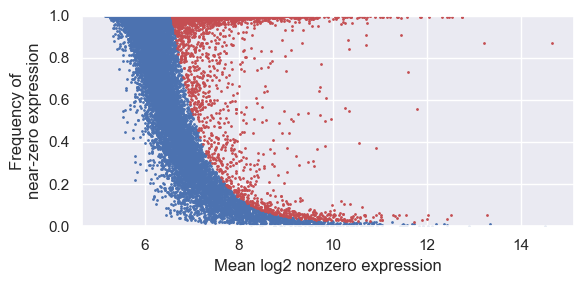

In [20]:
# Plot  
# Genes NOT selected for further analysis are in blue
# Genes selected for further analysis are in red; these genes have a high expression level (above threshold) when detected
# AND unusually high near-zero frequency
plt.figure(figsize=(6,3))
plt.scatter(x[~selectedGenes], y[~selectedGenes], s=1)
plt.scatter(x[selectedGenes],  y[selectedGenes], s=1, color='r')
plt.xlabel('Mean log2 nonzero expression')
plt.ylabel('Frequency of\nnear-zero expression')
plt.ylim([0,1])
plt.tight_layout()

## PCA  

### What is happening?  
The original expression matrix has many dimensions because each gene is a feature (see stats in previous blocks: 10 000 - 15 000 cells, and over 45 000 genes). Principal Component Analysis (PCA) combines different proportions of the features to produce principle components that capture maximal variance, so that the first principle component explains the most variance and each subsequent pricipal component explains less variance. There are as many principle components as there are features, although often a subset is kept. PCA is a dimensionality reduction method that maintains the structure of the data so that we can interpret it.  

Here the authors reduce the data to 50 dimensions before applying t-SNE.  

### Things I want to understand  
- Why 50 PCs?
- How much variance is retained?
- What does each PC represent?
- What happens if I use 10 PCs?
- What happens if I use 100 PCs?


In [23]:
%%time
# select genes according to selectedGenes mask
# normalise gene counts and log transform
# perform dimensionality reduction using PCA

counts3k = tasic2018['counts'][:, selectedGenes]  # Feature selection

librarySizes = tasic2018['counts'].sum(axis=1)    # Compute library sizes
CPM = counts3k / librarySizes * 1e+6              # Library size normalisation

logCPM = np.log2(CPM + 1)                         # Log-transformation - integer counts don't work well with subsequent methods
logCPM = np.asarray(logCPM)

pca = PCA(n_components=50, svd_solver='full').fit(logCPM)   # PCA

flipSigns = np.sum(pca.components_, axis=1) < 0             # fix PC signs
X = pca.transform(logCPM)
X[:, flipSigns] *= -1

print('Shape of the resulting matrix:', X.shape, '\n')

Shape of the resulting matrix: (23822, 50) 

CPU times: user 1min 53s, sys: 13.8 s, total: 2min 7s
Wall time: 20.4 s


In [ ]:
%%time  
# PCA with different PCs - TEST DIFFERENT PCs 
#num_PCs = [10, 50, 100]
#fig.axs = plt.subplots(len(PCs), figsize=(6, 4*len(PCs)))
#
#for ax, num_PC in zip(axs, num_PCs):
#    pca = PCA(n_components=num_PC, svd_solver=`full`).fit(logCPM)
#    flipSigns = np.sum(pca.components_, axis=1) < 0             # fix PC signs
#    X = pca.transform(logCPM)
#    X[:, flipSigns] *= -1



## Initial data exploration (PCA/MDS)

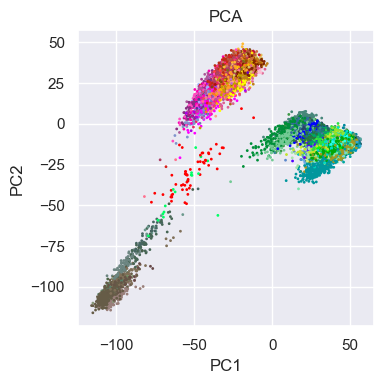

In [34]:
# Principal component analysis

plt.figure(figsize=(4,4))
plt.scatter(X[:,0], X[:,1], s=1, color=tasic2018['clusterColors'][tasic2018['clusters']])
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()

CPU times: user 302 ms, sys: 137 ms, total: 438 ms
Wall time: 77.5 ms


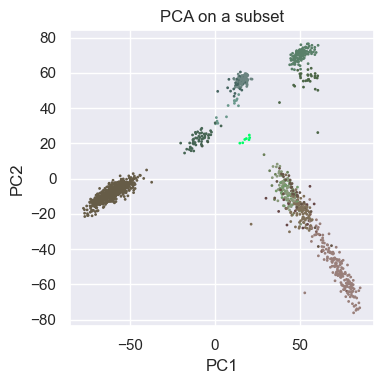

In [36]:
%%time

# PCA on a subset identified in the previous figure

subset = (X[:,0] < -50) & (X[:,1] < -50)
Xsubset = PCA(n_components=2).fit_transform(X[subset,:])

plt.figure(figsize=(4,4))
plt.scatter(Xsubset[:,0], Xsubset[:,1], s=1, 
            color=tasic2018['clusterColors'][tasic2018['clusters'][subset]])
plt.title('PCA on a subset')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()

/Users/anneke/opt/anaconda3/lib/python3.8/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


CPU times: user 2.03 s, sys: 635 ms, total: 2.67 s
Wall time: 378 ms


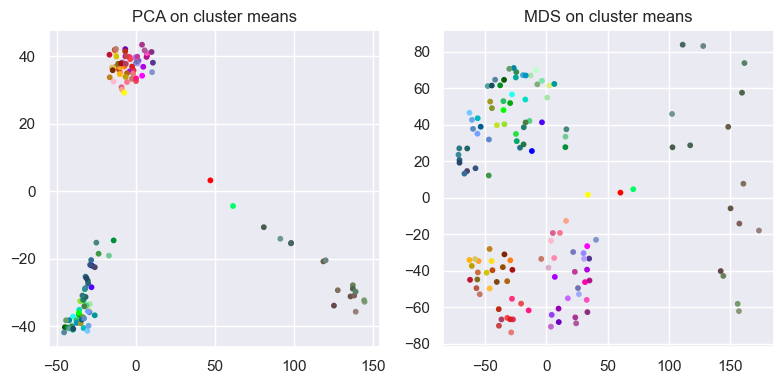

In [38]:
%%time

# If clustering results are available, do PCA and/or MDS on the cluster means

C = np.unique(tasic2018['clusters']).size
clusterMeans = np.zeros((C, X.shape[1]))
for c in range(C):
    clusterMeans[c,:] = np.mean(X[tasic2018['clusters']==c,:], axis=0)

clusterMeansPCA = PCA(n_components=2, svd_solver='full').fit_transform(clusterMeans)
clusterMeansMDS = MDS(n_components=2, random_state=42).fit_transform(clusterMeans)

plt.figure(figsize=(8,4))
plt.subplot(121)
plt.scatter(clusterMeansPCA[:,0], clusterMeansPCA[:,1], s=10, color=tasic2018['clusterColors'])
plt.title('PCA on cluster means')
plt.subplot(122)
plt.scatter(clusterMeansMDS[:,0], clusterMeansMDS[:,1], s=10, color=tasic2018['clusterColors'])
plt.title('MDS on cluster means')
plt.tight_layout()

In [5]:
# Simulate the dataset

X_huge = X.copy()
clusters_huge = tasic2018['clusters'].copy()
for i in range(9):
    X_huge = np.concatenate((X_huge,X))
    clusters_huge = np.concatenate((clusters_huge, tasic2018['clusters']))
X_huge += np.random.randn(*X_huge.shape) * 1.5

print('Simulated dataset size:', X_huge.shape)

Simulated dataset size: (238220, 50)


In [6]:
# This uses Euclidean distance in the PCA space. Only points that were not in the downsampled subset
# are positioned on the downsampled tSNE.

def map_to_downsampled_tsne(X, Z, downsampled_ind, batchsize=1000, knn=10):
    ind_rest = np.where(~np.isin(np.arange(X.shape[0]), downsampled_ind))[0]
    steps = int(np.ceil(ind_rest.size/batchsize))
    assignmentPositions = np.zeros((X.shape[0], 2))
    assignmentPositions[downsampled_ind,:] = Z
    
    def pdist2(A,B):
        return np.sum(A**2,axis=1)[:, None] + np.sum(B**2, axis=1)[None, :] - 2 * A @ B.T

    for i in range(steps):
        print('.', end='', flush=True)
        endind = np.min(((i+1)*batchsize, ind_rest.size))
        batch = ind_rest[i*batchsize:endind]
        D = pdist2(X[batch, :], X[downsampled_ind,:])
        ind = np.argpartition(D, knn)[:, :knn]
        for i in range(batch.size):
            assignmentPositions[batch[i],:] = np.median(Z[ind[i,:],:], axis=0)
    print('', flush=True)
    
    return assignmentPositions


# Pipeline for using downsampling-based initialisation
def downsampling_based_tsne(X, subsetSize=25000, seed=42, exaggeration=1):
    np.random.seed(seed)
    indSubset = np.random.choice(X.shape[0], subsetSize, replace=False)
    
    # Note that this assumes that X was already PCA-transformed
    pcaInit = X[:,:2] / np.std(X[:,0]) * 0.0001
    
    Zsubset = fast_tsne(X[indSubset,:], perplexity_list=[30, int(subsetSize/100)], 
                        initialization = pcaInit[indSubset,:],
                        learning_rate = subsetSize/12)

    pos = map_to_downsampled_tsne(X, Zsubset, indSubset)
    downsampled_init = pos / np.std(pos[:,0]) * 0.0001

    Z = fast_tsne(X, perplexity=30, initialization=downsampled_init, 
                  learning_rate=X.shape[0]/12, late_exag_coeff=exaggeration, 
                  start_late_exag_iter=250)
    
    return Z

In [9]:
%%time

# t-SNE with PCA initialisation and high learning rate (perplexity 30)
pcaInit = X_huge[:,:2] / np.std(X_huge[:,0]) * 0.0001
tsne1 = fast_tsne(X_huge, initialization=pcaInit, learning_rate=X_huge.shape[0]/12)

# t-SNE with downsampling-based initialisation and exaggeration
tsne2 = downsampling_based_tsne(X_huge, exaggeration=4)

......................................................................................................................................................................................................................
CPU times: user 5min 14s, sys: 33.4 s, total: 5min 48s
Wall time: 13min 41s


<IPython.core.display.Javascript object>


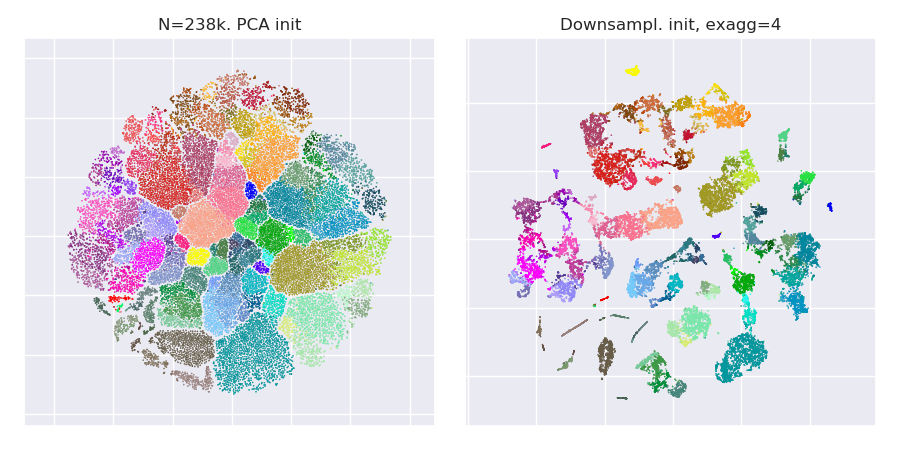

In [10]:
# Plot

tsnes  = [tsne1, tsne2]
titles = ['N=238k. PCA init', 'Downsampl. init, exagg=4']

plt.figure(figsize=(9,4.5))
for i,t in enumerate(tsnes):
    plt.subplot(1,2,i+1)
    plt.gca().set_aspect('equal', adjustable='datalim')
    plt.scatter(tsnes[i][:,0], tsnes[i][:,1], s=1, alpha=.2, edgecolor='none',
                color=tasic2018['clusterColors'][clusters_huge])
    plt.title(titles[i])
    plt.gca().get_xaxis().set_ticklabels([])
    plt.gca().get_yaxis().set_ticklabels([])
    
plt.tight_layout()